# ACC102 Mini Assignment – Track 2
## S&P 500 Sector Performance Dashboard
### Which Sectors Lead the Market — and When?

**Analytical Problem:** Investors and finance students often lack a clear picture of how different stock market sectors perform relative to each other over time. This notebook answers: *Which S&P 500 sectors delivered the best returns, lowest volatility, and strongest risk-adjusted performance from 2020 to 2024?*

**Target User:** Finance students and individual investors seeking a data-driven view of U.S. equity sector dynamics.

**Data Source:** Yahoo Finance via the `yfinance` Python library. SPDR Sector ETFs are used as proxies for each S&P 500 GICS sector. Data accessed: April 2026.

**Track:** Track 2 – GitHub Data Analysis Project

In [2]:
!pip install yfinance

# Install required packages if needed
# !pip install yfinance pandas matplotlib seaborn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

print('All packages loaded successfully.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 5.2 MB/s  0:00:006.0 MB/s eta 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=88fd84a8bf1ac61a55c298eaac0e8187aaf472ca814918e9f0c410a698882d3b
  Stored in directory: /Users/yangmaini/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]━━ 3/5 [curl_cffi]
All packages loaded successfully.


## 1. Parameters

We store all key variables as parameters at the top of the notebook.
This mirrors the Week 5–6 approach of using **parameterised variables** (like f-strings in SQL queries) so the entire workflow can be rerun simply by changing the values here — no need to edit individual cells.

In [3]:
# ── PARAMETERS (change these to re-run for any period) ──────────────────────
START_DATE = '2020-01-01'
END_DATE   = '2024-12-31'
RISK_FREE  = 0.045   # approximate annualised US risk-free rate (5-yr avg)

# S&P 500 GICS sector ETFs (SPDR)
SECTOR_TICKERS = {
    'Technology'        : 'XLK',
    'Financials'        : 'XLF',
    'Healthcare'        : 'XLV',
    'Consumer Discret.' : 'XLY',
    'Industrials'       : 'XLI',
    'Energy'            : 'XLE',
    'Utilities'         : 'XLU',
    'Real Estate'       : 'XLRE',
    'Materials'         : 'XLB',
    'Comm. Services'    : 'XLC',
    'Consumer Staples'  : 'XLP',
}

print(f'Analysis period : {START_DATE}  →  {END_DATE}')
print(f'Sectors tracked : {len(SECTOR_TICKERS)}')
print(f'Risk-free rate  : {RISK_FREE*100:.1f}% p.a.')

Analysis period : 2020-01-01  →  2024-12-31
Sectors tracked : 11
Risk-free rate  : 4.5% p.a.


## 2. Data Acquisition

We wrap the download in a **reusable function** — following the Week 6 principle of turning workflows into functions for reuse and cleaner code.

- Input: ticker dictionary, start date, end date
- Output: a clean pandas DataFrame (columns = sector names, index = date)

In [ ]:
def fetch_sector_prices(tickers_dict: dict, start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted closing prices for all sector ETFs.

    Parameters
    ----------
    tickers_dict : dict  {sector_name: ticker_symbol}
    start        : str   start date 'YYYY-MM-DD'
    end          : str   end date   'YYYY-MM-DD'

    Returns
    -------
    pd.DataFrame  columns = sector names, index = date
    """
    symbols = list(tickers_dict.values())
    names   = list(tickers_dict.keys())

    # Download raw data from Yahoo Finance
    raw = yf.download(symbols, start=start, end=end,
                      auto_adjust=True, progress=False)
    prices = raw['Close'].copy()

    # Rename ticker columns -> readable sector names
    rename_map = {v: k for k, v in tickers_dict.items()}
    prices = prices.rename(columns=rename_map)

    # Keep only the sectors we requested (in the intended order)
    prices = prices[[n for n in names if n in prices.columns]]

    # ── Defensive check 1: flag tickers that returned no data at all ─────────
    missing = prices.columns[prices.isna().all()].tolist()
    if missing:
        print(f'Warning: no data returned for {missing} '
              f'- check ticker symbols or date range.')
        prices = prices.drop(columns=missing)

    # Drop rows where ALL values are missing
    prices = prices.dropna(how='all')

    # ── Defensive check 2: report sectors with short history ─────────────────
    # e.g. XLC only started trading in June 2018. If START_DATE is pushed
    # earlier, this surfaces the short-history sectors instead of silently
    # truncating or padding them.
    coverage = pd.DataFrame({
        'first_date': prices.apply(lambda s: s.first_valid_index()),
        'last_date':  prices.apply(lambda s: s.last_valid_index()),
        'n_obs':      prices.count(),
    })
    short_hist = coverage[
        coverage['first_date'] > pd.Timestamp(start) + pd.Timedelta(days=5)
    ]
    if not short_hist.empty:
        print('Sectors with shorter-than-requested history:')
        print(short_hist)

    return prices


# Run the function
prices = fetch_sector_prices(SECTOR_TICKERS, START_DATE, END_DATE)

print(f'Shape          : {prices.shape}  (rows = trading days, cols = sectors)')
print(f'Date range     : {prices.index[0].date()}  ->  {prices.index[-1].date()}')
print(f'Missing values : {prices.isna().sum().sum()}')
prices.head()

## 3. Data Cleaning and Preparation

We use standard pandas operations from class:

- `.dtypes` — inspect data types
- `.ffill()` — forward-fill isolated missing trading days
- `.pct_change()` — compute daily returns
- `.cumprod()` — compute cumulative return index
- `.index.year` / `.index.month` — extract date components (same as `.dt.year` taught in Week 6)

In [ ]:
# ── 3a. Inspect data types ───────────────────────────────────────────────────
print('Data types:')
print(prices.dtypes)
print()

# ── 3b. Inspect missing values BEFORE filling ────────────────────────────────
# ffill can mask data-quality issues, so we look first and only fill if needed.
# US ETFs rarely halt, so this is usually a no-op; if a sector has many NaNs,
# that's a signal to investigate rather than silently forward-fill.
na_before = prices.isna().sum()
if na_before.sum() > 0:
    print('Missing values per sector (before ffill):')
    print(na_before[na_before > 0])
    prices = prices.ffill()
    print(f'\nMissing values after ffill: {prices.isna().sum().sum()}')
else:
    print('No missing values - ffill not needed.')

In [7]:
# ── 3c. Compute daily returns ────────────────────────────────────────────────
daily_returns = prices.pct_change().dropna()

# ── 3d. Cumulative return index, rebased to 100 at start ────────────────────
cum_returns = (1 + daily_returns).cumprod() * 100

# ── 3e. Add year and month columns (same as .dt.year in lecture) ─────────────
daily_returns_annotated = daily_returns.copy()
daily_returns_annotated['year']  = daily_returns.index.year
daily_returns_annotated['month'] = daily_returns.index.month

print('Daily returns (first 3 rows):')
print(daily_returns.head(3).round(4))
print()
print('Cumulative return index (first 3 rows):')
print(cum_returns.head(3).round(2))

Daily returns (first 3 rows):
Ticker      Technology  Financials  Healthcare  Consumer Discret.  \
Date                                                                
2020-01-03     -0.0112     -0.0106     -0.0087            -0.0085   
2020-01-06      0.0024     -0.0007      0.0062             0.0028   
2020-01-07     -0.0004     -0.0065     -0.0020            -0.0016   

Ticker      Industrials  Energy  Utilities  Real Estate  Materials  \
Date                                                                 
2020-01-03      -0.0019 -0.0030     0.0020       0.0073    -0.0161   
2020-01-06       0.0004  0.0078     0.0009       0.0003    -0.0044   
2020-01-07      -0.0021 -0.0026    -0.0014      -0.0109    -0.0012   

Ticker      Comm. Services  Consumer Staples  
Date                                          
2020-01-03         -0.0065           -0.0016  
2020-01-06          0.0134            0.0021  
2020-01-07          0.0013           -0.0077  

Cumulative return index (first 3 rows

## 4. Analysis

### 4a. Summary Statistics

We compute five metrics for each sector, wrapped in a reusable function:

| Metric | Definition |
|---|---|
| Ann. Return (%) | Mean daily return × 252 |
| Ann. Volatility (%) | Std of daily returns × √252 |
| Sharpe Ratio | Annualised excess return ÷ annualised volatility |
| Max Drawdown (%) | Largest peak-to-trough decline |
| Total Return (%) | Compound return over the full period |

In [ ]:
def max_drawdown(ret_series: pd.Series) -> float:
    """Largest peak-to-trough decline, in percent (negative number)."""
    cum         = (1 + ret_series).cumprod()
    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    return round(drawdown.min() * 100, 2)


def compute_summary_stats(daily_ret: pd.DataFrame,
                          risk_free_annual: float,
                          trading_days: int = 252) -> pd.DataFrame:
    """
    Compute key performance metrics for each sector.

    Uses the direct annualisation form so each metric reads 1:1 with its
    definition:
        ann_return = mean(daily) * 252
        ann_vol    = std(daily)  * sqrt(252)
        sharpe     = (ann_return - rf_annual) / ann_vol

    Note: rf is applied as a simple annual rate. For a strict compounded-daily
    equivalent use (1 + rf)**(1/252) - 1; at rf ~ 4.5% the difference is
    negligible (<1 bp per day).

    Parameters
    ----------
    daily_ret         : pd.DataFrame  daily return series per sector
    risk_free_annual  : float         annualised risk-free rate
    trading_days      : int           annualisation factor (default 252)

    Returns
    -------
    pd.DataFrame sorted by Sharpe Ratio (descending)
    """
    ann_return = daily_ret.mean() * trading_days
    ann_vol    = daily_ret.std()  * np.sqrt(trading_days)
    sharpe     = (ann_return - risk_free_annual) / ann_vol

    stats = pd.DataFrame(index=daily_ret.columns)
    stats['Ann. Return (%)']     = (ann_return * 100).round(2)
    stats['Ann. Volatility (%)'] = (ann_vol * 100).round(2)
    stats['Sharpe Ratio']        = sharpe.round(2)
    stats['Max Drawdown (%)']    = daily_ret.apply(max_drawdown)
    stats['Total Return (%)']    = ((daily_ret + 1).prod() - 1).mul(100).round(2)

    return stats.sort_values('Sharpe Ratio', ascending=False)


summary = compute_summary_stats(daily_returns, RISK_FREE)
print('=== Sector Performance Summary (sorted by Sharpe Ratio) ===')
summary

### 4b. Annual Returns — Sector Rotation View

Grouping daily returns by year reveals which sector led in each calendar year.
This is the pandas `.groupby()` operation applied to the date index.

In [9]:
# Annual returns per sector (%)
annual_returns = daily_returns.groupby(daily_returns.index.year).apply(
    lambda x: (x + 1).prod() - 1
) * 100

print('Annual returns by sector (%):')
annual_returns.round(1)

Annual returns by sector (%):


Ticker,Technology,Financials,Healthcare,Consumer Discret.,Industrials,Energy,Utilities,Real Estate,Materials,Comm. Services,Consumer Staples
Date,,,,,,,,,,,
2020,41.0,-2.7,13.0,28.1,8.8,-33.3,1.8,-1.0,21.9,25.4,11.0
2021,34.7,34.8,26.0,27.9,21.1,53.3,17.7,46.1,27.4,16.0,17.2
2022,-27.7,-10.6,-2.1,-36.3,-5.6,64.3,1.4,-26.2,-12.3,-37.6,-0.8
2023,56.0,12.0,2.1,39.6,18.1,-0.6,-7.2,12.4,12.5,52.8,-0.8
2024,22.7,30.4,2.2,27.5,17.5,4.2,23.4,4.3,-0.3,35.2,11.9


## 5. Visualisations

Six charts communicate the analysis results to the target user.
All charts are saved to the `/figures/` folder.

> **Note:** create the folder before running: `import os; os.makedirs('figures', exist_ok=True)`

In [12]:
import os
os.makedirs('figures', exist_ok=True)
print('figures/ folder ready.')

figures/ folder ready.


### Chart 1 — Cumulative Returns
Shows how $100 invested in each sector at the start of 2020 would have grown by end of 2024.

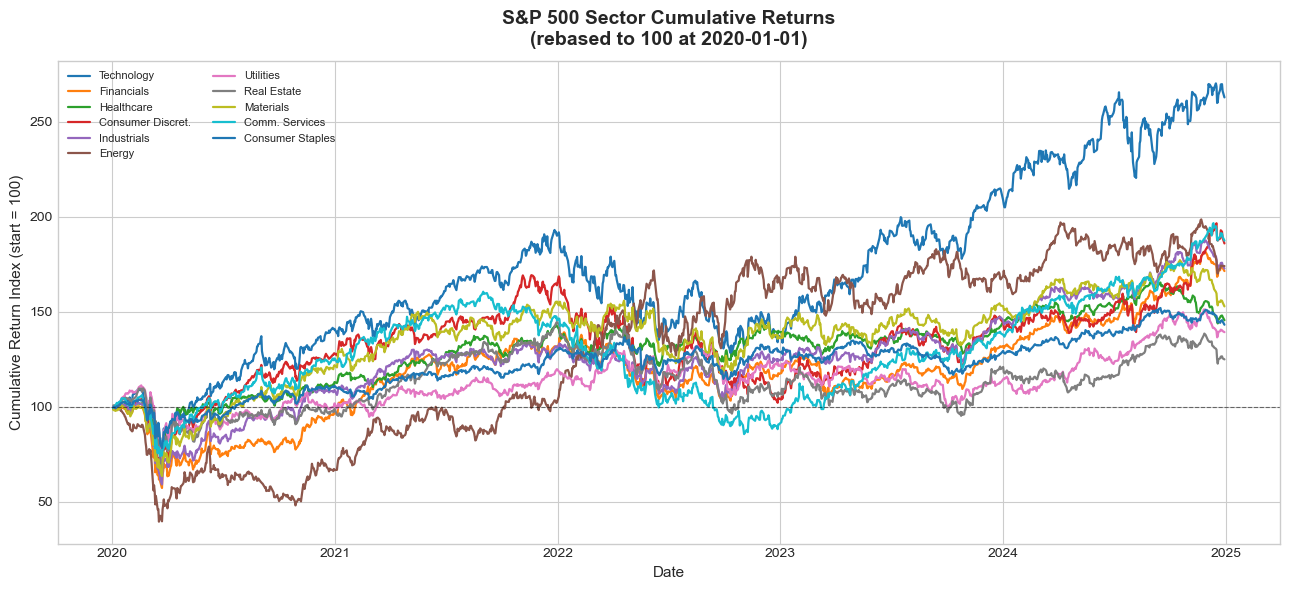

Chart 1 saved.


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))

for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], linewidth=1.6, label=col)

ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title(f'S&P 500 Sector Cumulative Returns\n(rebased to 100 at {START_DATE})',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Cumulative Return Index (start = 100)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/chart1_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

### Chart 2 — Risk vs. Return Scatter
Each point = one sector. X-axis = annualised volatility (risk), Y-axis = annualised return.
Sectors in the upper-left are most desirable (high return, low risk).

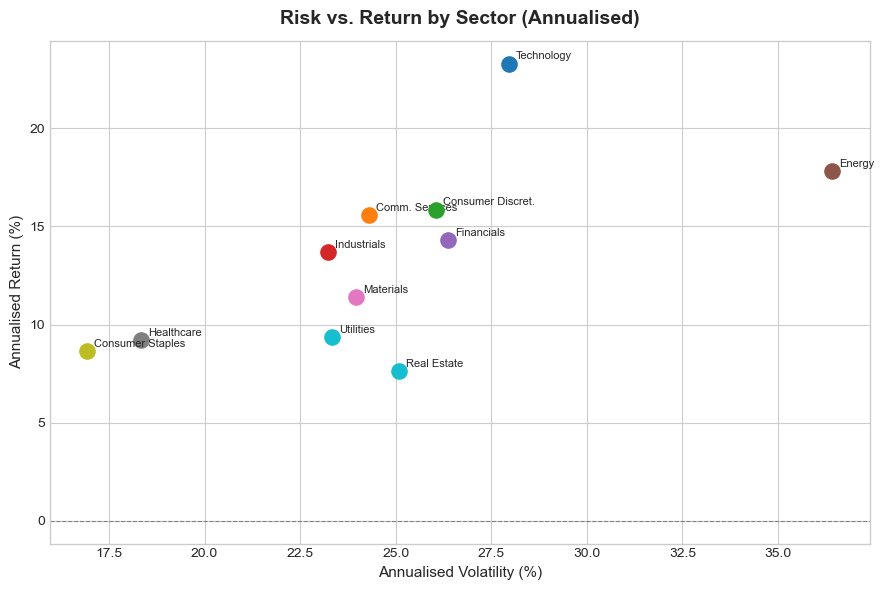

Chart 2 saved.


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))

for i, (sector, row) in enumerate(summary.iterrows()):
    ax.scatter(row['Ann. Volatility (%)'], row['Ann. Return (%)'],
               s=120, color=colors[i], zorder=3)
    ax.annotate(sector,
                xy=(row['Ann. Volatility (%)'], row['Ann. Return (%)']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Risk vs. Return by Sector (Annualised)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Return (%)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/chart2_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

### Chart 3 — Sharpe Ratio Bar Chart
The Sharpe Ratio measures risk-adjusted return: how much excess return a sector earns per unit of risk.
Green = positive (return exceeds risk-free rate), Red = negative.




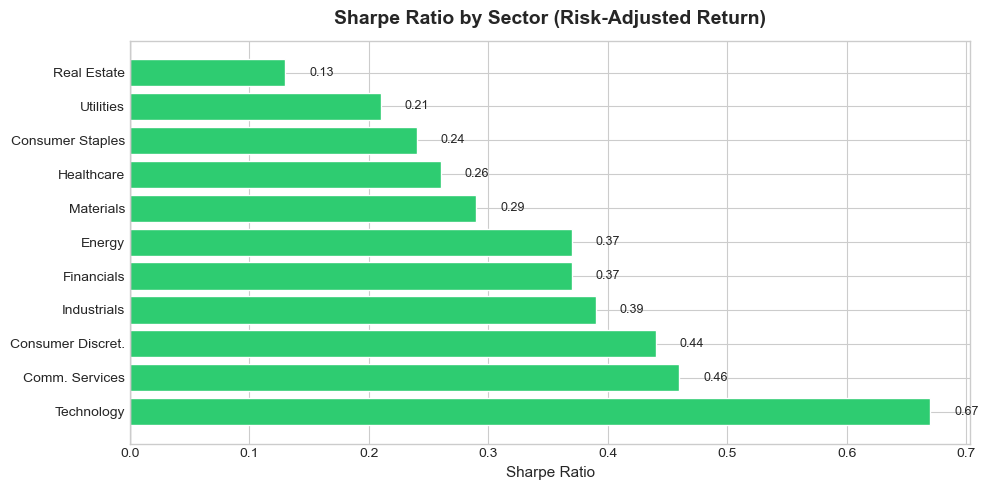

Chart 3 saved.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#2ecc71' if v > 0 else '#e74c3c'
              for v in summary['Sharpe Ratio']]
bars = ax.barh(summary.index, summary['Sharpe Ratio'],
               color=bar_colors, edgecolor='white')

for bar, val in zip(bars, summary['Sharpe Ratio']):
    ax.text(val + 0.02 if val >= 0 else val - 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sharpe Ratio by Sector (Risk-Adjusted Return)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sharpe Ratio', fontsize=11)
plt.tight_layout()
plt.savefig('figures/chart3_sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

### Chart 4 — Rolling 30-Day Volatility
Shows how risk evolved over time. The COVID-19 shock (March 2020) is clearly visible as a spike across all sectors simultaneously.

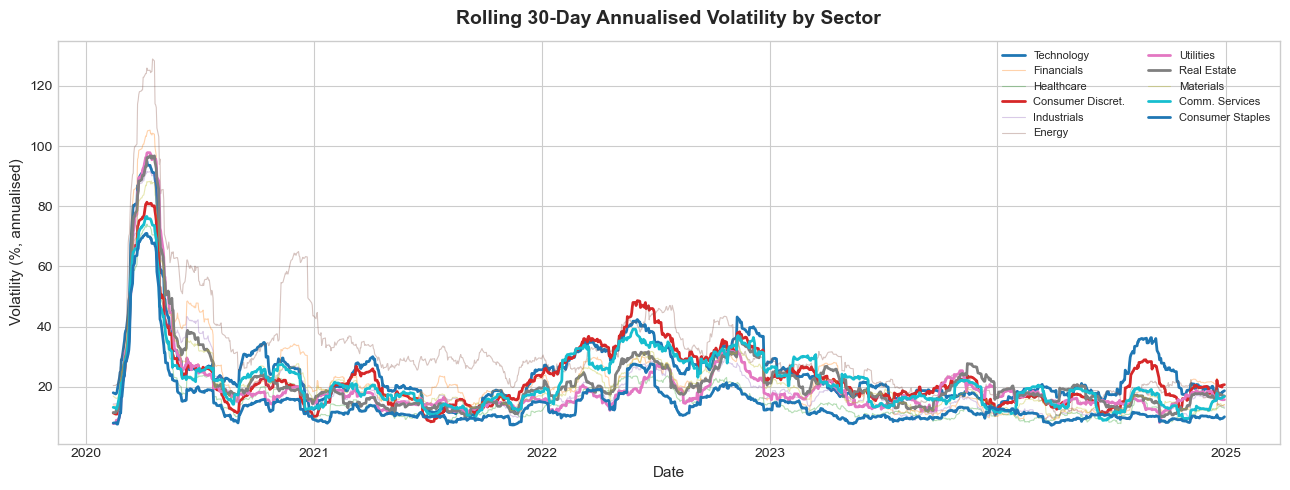

Chart 4 saved.


In [16]:
rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252) * 100

# Highlight top-3 and bottom-3 by Sharpe Ratio
top3    = summary.head(3).index.tolist()
bottom3 = summary.tail(3).index.tolist()
highlight = top3 + bottom3

fig, ax = plt.subplots(figsize=(13, 5))

for col in rolling_vol.columns:
    lw    = 2.0 if col in highlight else 0.8
    alpha = 1.0 if col in highlight else 0.35
    ax.plot(rolling_vol.index, rolling_vol[col],
            linewidth=lw, alpha=alpha, label=col)

ax.set_title('Rolling 30-Day Annualised Volatility by Sector',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Volatility (%, annualised)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/chart4_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

### Chart 5 — Correlation Heatmap
Shows how closely sector returns move together. Values near 1.0 = highly correlated (move together). Lower values indicate better diversification potential.

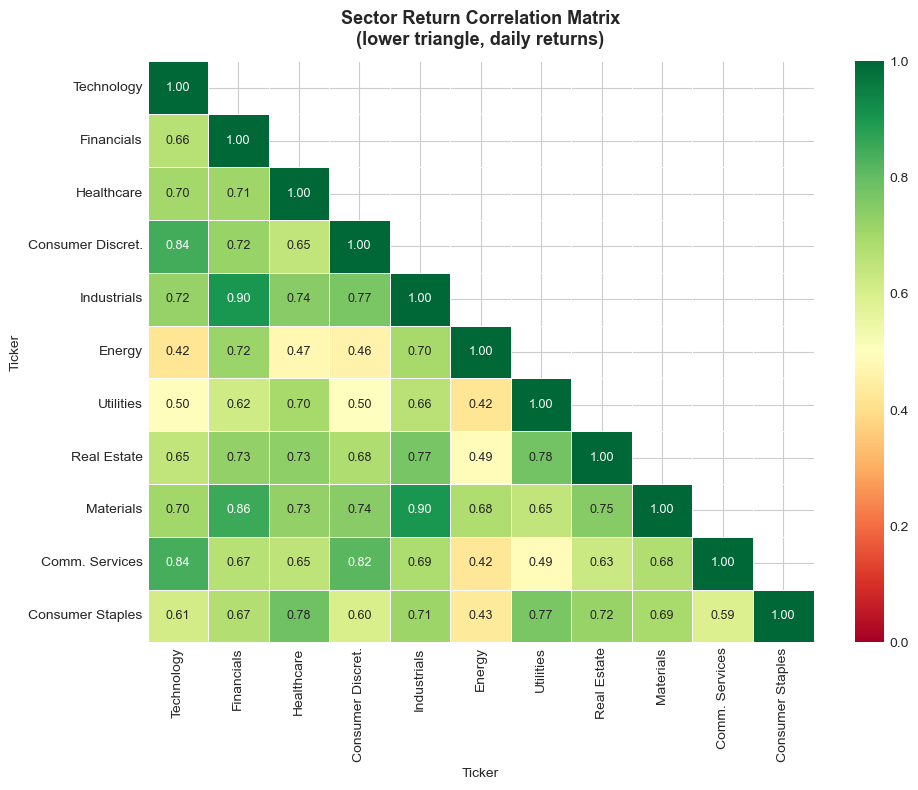

Chart 5 saved.


In [17]:
corr_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Sector Return Correlation Matrix\n(lower triangle, daily returns)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

### Chart 6 — Annual Returns Heatmap (Sector Rotation)
Each cell = one sector's return in one calendar year. Red = negative, Green = positive.
This view reveals sector rotation — which sectors led in each economic environment.

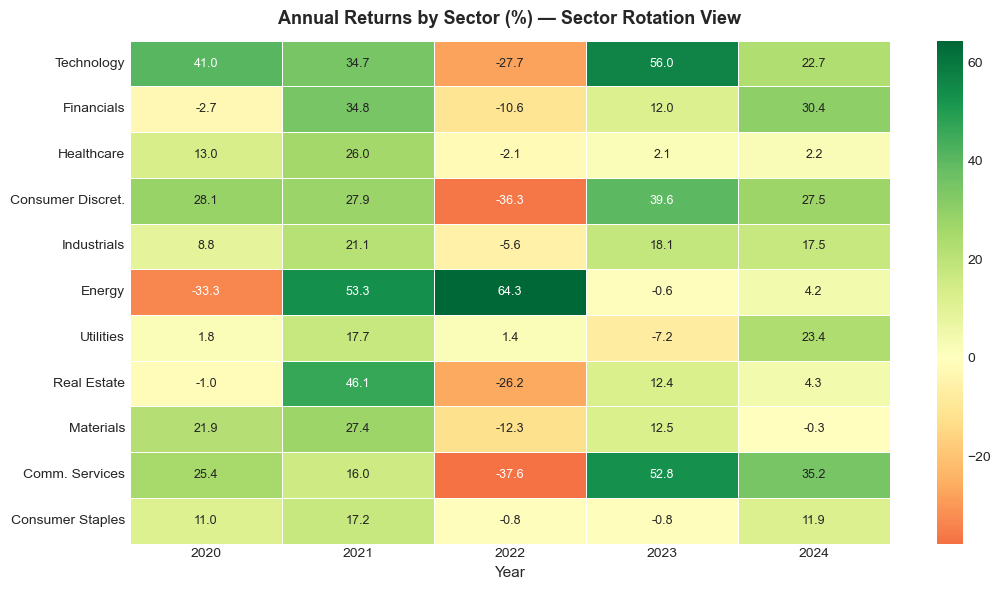

Chart 6 saved.


In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(annual_returns.T, annot=True, fmt='.1f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Annual Returns by Sector (%) — Sector Rotation View',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('figures/chart6_annual_rotation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

## 6. Key Insights

In [19]:
best_sharpe  = summary['Sharpe Ratio'].idxmax()
worst_sharpe = summary['Sharpe Ratio'].idxmin()
best_return  = summary['Total Return (%)'].idxmax()
lowest_vol   = summary['Ann. Volatility (%)'].idxmin()
deepest_dd   = summary['Max Drawdown (%)'].idxmin()

print('=' * 60)
print('                   KEY FINDINGS')
print('=' * 60)
print(f'Best risk-adjusted return  → {best_sharpe}')
print(f'  Sharpe : {summary.loc[best_sharpe, "Sharpe Ratio"]:.2f}  |  '
      f'Ann. Return : {summary.loc[best_sharpe, "Ann. Return (%)"]:.1f}%')
print()
print(f'Highest total return       → {best_return}')
print(f'  Total return : {summary.loc[best_return, "Total Return (%)"]:.1f}%')
print()
print(f'Lowest volatility (safest) → {lowest_vol}')
print(f'  Ann. vol : {summary.loc[lowest_vol, "Ann. Volatility (%)"]:.1f}%')
print()
print(f'Worst risk-adjusted return → {worst_sharpe}')
print(f'  Sharpe : {summary.loc[worst_sharpe, "Sharpe Ratio"]:.2f}')
print()
print(f'Deepest drawdown           → {deepest_dd}')
print(f'  Max DD : {summary.loc[deepest_dd, "Max Drawdown (%)"]:.1f}%')
print('=' * 60)
print()
print('Full summary table (sorted by Sharpe Ratio):')
print(summary.to_markdown())

                   KEY FINDINGS
Best risk-adjusted return  → Technology
  Sharpe : 0.67  |  Ann. Return : 23.3%

Highest total return       → Technology
  Total return : 162.7%

Lowest volatility (safest) → Consumer Staples
  Ann. vol : 16.9%

Worst risk-adjusted return → Real Estate
  Sharpe : 0.13

Deepest drawdown           → Energy
  Max DD : -60.6%

Full summary table (sorted by Sharpe Ratio):
| Ticker            |   Ann. Return (%) |   Ann. Volatility (%) |   Sharpe Ratio |   Max Drawdown (%) |   Total Return (%) |
|:------------------|------------------:|----------------------:|---------------:|-------------------:|-------------------:|
| Technology        |             23.3  |                 27.96 |           0.67 |             -33.56 |             162.71 |
| Comm. Services    |             15.57 |                 24.31 |           0.46 |             -46.65 |              87.37 |
| Consumer Discret. |             15.86 |                 26.06 |           0.44 |             -39

## 7. Limitations

- **ETF proxy bias** — SPDR ETFs carry small tracking errors and expense ratios vs. the pure GICS index
- **Fixed risk-free rate** — held constant at 4.5%; actual rates ranged from ~0% (2020–21) to >5% (2023)
- **Simple-rate rf approximation** — the Sharpe calculation treats rf as a simple annual rate rather than its compounded-daily equivalent `(1 + rf)**(1/252) - 1`; the difference at rf ≈ 4.5% is under 1 bp/day and does not change the cross-sector ranking
- **COVID-19 distortion** — the March 2020 crash inflates long-run volatility estimates
- **Survivorship bias** — current ETF constituents reflect today's index composition, not historical composition
- **No macro context** — sector performance shown in isolation, without linking to interest rate cycles or GDP

---
*ACC102 Mini Assignment – Track 2 | Xi'an Jiaotong-Liverpool University | 2024-25 Semester 2*